# WASH Africa Analysis — Exploratory Data Analysis (EDA)
**Project:** Community Water and Sanitation Access Survey Analysis
(WASH) in Africa  
**Data Source:** WHO/UNICEF Joint Monitoring Programme (JMP) 2025  
**Tool:** Python (pandas, matplotlib, seaborn)  
**Author:** Clement Etim  
**Date:** May 2026

---

## About This Notebook
This notebook covers Phase 2 of the analysis: exploratory data
analysis (EDA) of the cleaned WASH dataset for Sub-Saharan Africa.

We examine access to water, sanitation, and hygiene services across
45 countries, focusing on four themes:
1. Overall access levels by country and sub-region
2. Rural vs. urban disparities
3. Progress from 2000 to 2024
4. Best and worst performing countries

## Step 1 — Installing and Importing Libraries
We use pandas for data manipulation, matplotlib and seaborn for
visualisation.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# Set visual style for all charts
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 11

print("Libraries loaded successfully.")

Libraries loaded successfully.


## Step 2 — Load the Clean Datasets
We load the cleaned datasets exported in Phase 1. We use the latest
year snapshot for cross-country comparisons and the full time series
for trend analysis.

In [2]:
# Upload africa_wash_clean.xlsx to Colab before running this cell

file_path = "/content/africa_wash_clean.xlsx"

# Time series
wat_trend = pd.read_excel(file_path, sheet_name="Water_TimeSeries")
san_trend = pd.read_excel(file_path, sheet_name="San_TimeSeries")
hyg_trend = pd.read_excel(file_path, sheet_name="Hyg_TimeSeries")

# Latest year snapshots
wat_latest = pd.read_excel(file_path, sheet_name="Water_Latest")
san_latest = pd.read_excel(file_path, sheet_name="San_Latest")
hyg_latest = pd.read_excel(file_path, sheet_name="Hyg_Latest")

print("Datasets loaded successfully.")
print(f"\nTime series — Water: {wat_trend.shape}, Sanitation: {san_trend.shape}, Hygiene: {hyg_trend.shape}")
print(f"Latest year — Water: {wat_latest.shape}, Sanitation: {san_latest.shape}, Hygiene: {hyg_latest.shape}")

Datasets loaded successfully.

Time series — Water: (1096, 20), Sanitation: (1094, 20), Hygiene: (770, 17)
Latest year — Water: (45, 20), Sanitation: (45, 20), Hygiene: (43, 17)


## Step 3 — Descriptive Statistics
We begin with a summary of access rates across all
45 countries. This gives us a
continental overview; the average, minimum, and maximum access
rates for water, sanitation, and hygiene across Sub-Saharan Africa.

In [3]:
indicators = {
    "Basic Water Access (%)": wat_latest["Water_Basic_Total"],
    "Safely Managed Water (%)": wat_latest["Water_SafelyManaged_Total"],
    "Basic Sanitation Access (%)": san_latest["San_Basic_Total"],
    "Safely Managed Sanitation (%)": san_latest["San_SafelyManaged_Total"],
    "Open Defecation (%)": san_latest["San_OpenDefecation_Total"],
    "Basic Hygiene Access (%)": hyg_latest["Hyg_Basic_Total"],
}

print("=" * 60)
print("SUB-SAHARAN AFRICA — WASH ACCESS OVERVIEW (LATEST YEAR)")
print("=" * 60)

for name, series in indicators.items():
    print(f"\n{name}")
    print(f"  Average:  {series.mean():.1f}%")
    print(f"  Minimum:  {series.min():.1f}%")
    print(f"  Maximum:  {series.max():.1f}%")
    print(f"  Countries with data: {series.notna().sum()}")

SUB-SAHARAN AFRICA — WASH ACCESS OVERVIEW (LATEST YEAR)

Basic Water Access (%)
  Average:  70.2%
  Minimum:  35.7%
  Maximum:  92.3%
  Countries with data: 45

Safely Managed Water (%)
  Average:  28.9%
  Minimum:  6.2%
  Maximum:  68.0%
  Countries with data: 25

Basic Sanitation Access (%)
  Average:  40.0%
  Minimum:  10.4%
  Maximum:  83.1%
  Countries with data: 45

Safely Managed Sanitation (%)
  Average:  27.1%
  Minimum:  8.1%
  Maximum:  73.8%
  Countries with data: 29

Open Defecation (%)
  Average:  17.6%
  Minimum:  0.0%
  Maximum:  67.0%
  Countries with data: 45

Basic Hygiene Access (%)
  Average:  27.6%
  Minimum:  3.5%
  Maximum:  60.9%
  Countries with data: 43


## Step 4 — Top and Bottom Performing Countries
We identify the five best and five worst performing countries
for each WASH indicator using the latest available data. This
highlights where progress has been made and where the greatest
needs remain across Sub-Saharan Africa.

In [4]:
def top_bottom(df, column, label, n=5):
    valid = df[["Country", column]].dropna().sort_values(column, ascending=False)
    print(f"\n{label}")
    print(f"  Top {n}:")
    for _, row in valid.head(n).iterrows():
        print(f"    {row['Country']:<35} {row[column]:.1f}%")
    print(f"  Bottom {n}:")
    for _, row in valid.tail(n).iterrows():
        print(f"    {row['Country']:<35} {row[column]:.1f}%")

print("=" * 60)
print("TOP AND BOTTOM PERFORMERS — LATEST YEAR")
print("=" * 60)

top_bottom(wat_latest, "Water_Basic_Total", "Basic Water Access")
top_bottom(san_latest, "San_Basic_Total", "Basic Sanitation Access")
top_bottom(san_latest, "San_OpenDefecation_Total", "Open Defecation (lower is better)")
top_bottom(hyg_latest, "Hyg_Basic_Total", "Basic Hygiene Access")

TOP AND BOTTOM PERFORMERS — LATEST YEAR

Basic Water Access
  Top 5:
    Cabo Verde                          92.3%
    Botswana                            91.8%
    South Africa                        90.2%
    Ghana                               89.9%
    Gabon                               88.6%
  Bottom 5:
    Eritrea                             51.8%
    Burkina Faso                        50.0%
    South Sudan                         39.7%
    Central African Republic            36.5%
    Democratic Republic of the Congo    35.7%

Basic Sanitation Access
  Top 5:
    Cabo Verde                          83.1%
    Rwanda                              81.3%
    South Africa                        77.4%
    Botswana                            72.1%
    Equatorial Guinea                   66.3%
  Bottom 5:
    South Sudan                         14.4%
    Central African Republic            14.0%
    Chad                                13.1%
    Eritrea                             11.9%

## Step 5 — Rural vs. Urban Disparities
One of the most important dimensions of WASH analysis is the gap
between rural and urban access. People in rural areas
have lower access to water, sanitation, and hygiene services due to
infrastructure gaps, lower investment, and harder-to-reach locations.

We calculate the rural-urban gap for each country as:
Gap = Urban Access (%) minus Rural Access (%)

A larger gap means greater inequality within a country. A gap close
to zero means relatively equal access between urban and rural areas.

In [5]:
# Calculate rural-urban gaps
wat_latest["Water_RuralUrban_Gap"] = (
    wat_latest["Water_Basic_Urban"] - wat_latest["Water_Basic_Rural"]
)
san_latest["San_RuralUrban_Gap"] = (
    san_latest["San_Basic_Urban"] - san_latest["San_Basic_Rural"]
)
hyg_latest["Hyg_RuralUrban_Gap"] = (
    hyg_latest["Hyg_Basic_Urban"] - hyg_latest["Hyg_Basic_Rural"]
)

print("=" * 60)
print("RURAL VS. URBAN GAP — LATEST YEAR")
print("=" * 60)

for label, df, col in [
    ("Basic Water Access", wat_latest, "Water_RuralUrban_Gap"),
    ("Basic Sanitation Access", san_latest, "San_RuralUrban_Gap"),
    ("Basic Hygiene Access", hyg_latest, "Hyg_RuralUrban_Gap"),
]:
    valid = df[["Country", col]].dropna().sort_values(col, ascending=False)
    print(f"\n{label} — Rural/Urban Gap (Urban minus Rural)")
    print(f"  Average gap: {valid[col].mean():.1f} percentage points")
    print(f"  Largest gap (most unequal):")
    for _, row in valid.head(3).iterrows():
        print(f"    {row['Country']:<35} {row[col]:.1f} pts")
    print(f"  Smallest gap (most equal):")
    for _, row in valid.tail(3).iterrows():
        print(f"    {row['Country']:<35} {row[col]:.1f} pts")

RURAL VS. URBAN GAP — LATEST YEAR

Basic Water Access — Rural/Urban Gap (Urban minus Rural)
  Average gap: 28.0 percentage points
  Largest gap (most unequal):
    Eritrea                             61.9 pts
    Equatorial Guinea                   47.3 pts
    Burkina Faso                        47.1 pts
  Smallest gap (most equal):
    Cabo Verde                          8.9 pts
    Comoros                             7.0 pts
    Sao Tome and Principe               6.0 pts

Basic Sanitation Access — Rural/Urban Gap (Urban minus Rural)
  Average gap: 18.1 percentage points
  Largest gap (most unequal):
    Mauritania                          54.8 pts
    Niger                               44.4 pts
    Mozambique                          40.9 pts
  Smallest gap (most equal):
    Lesotho                             -4.1 pts
    Eswatini                            -22.6 pts
    Rwanda                              -30.4 pts

Basic Hygiene Access — Rural/Urban Gap (Urban minus Rural)
  Av

## Step 6 — Progress Analysis: 2000 vs. 2024
We now examine how access rates have changed over time by comparing
each country's earliest available data point (around 2000) with its
most recent data point (around 2024). This shows which countries
have made the most progress over the past two decades and which
have stagnated or declined.

In [6]:
def progress_analysis(df, column, label):
    # Get earliest and latest year per country
    earliest = df.sort_values("Year").groupby("Country").first().reset_index()[["Country", "Year", column]]
    latest = df.sort_values("Year").groupby("Country").last().reset_index()[["Country", "Year", column]]

    # Merge and calculate change
    progress = earliest.merge(latest, on="Country", suffixes=("_Start", "_End"))
    progress["Change"] = progress[f"{column}_End"] - progress[f"{column}_Start"]
    progress = progress.dropna(subset=["Change"]).sort_values("Change", ascending=False)

    print(f"\n{label}")
    print(f"  Average change: +{progress['Change'].mean():.1f} percentage points")
    print(f"  Most improved:")
    for _, row in progress.head(3).iterrows():
        print(f"    {row['Country']:<35} +{row['Change']:.1f} pts "
              f"({row[f'{column}_Start']:.1f}% → {row[f'{column}_End']:.1f}%)")
    print(f"  Least improved:")
    for _, row in progress.tail(3).iterrows():
        print(f"    {row['Country']:<35} {row['Change']:.1f} pts "
              f"({row[f'{column}_Start']:.1f}% → {row[f'{column}_End']:.1f}%)")

print("=" * 60)
print("PROGRESS ANALYSIS: 2000 vs. 2024")
print("=" * 60)

progress_analysis(wat_trend, "Water_Basic_Total", "Basic Water Access")
progress_analysis(san_trend, "San_Basic_Total", "Basic Sanitation Access")
progress_analysis(san_trend, "San_OpenDefecation_Total", "Open Defecation (negative change = improvement)")
progress_analysis(hyg_trend, "Hyg_Basic_Total", "Basic Hygiene Access")

PROGRESS ANALYSIS: 2000 vs. 2024

Basic Water Access
  Average change: +17.5 percentage points
  Most improved:
    Somalia                             +48.7 pts (26.6% → 75.3%)
    Mozambique                          +43.2 pts (23.4% → 66.6%)
    Nigeria                             +37.8 pts (44.5% → 82.2%)
  Least improved:
    Comoros                             -2.3 pts (87.3% → 85.1%)
    Burkina Faso                        -5.6 pts (55.6% → 50.0%)
    Central African Republic            -22.5 pts (59.0% → 36.5%)

Basic Sanitation Access
  Average change: +17.6 percentage points
  Most improved:
    Cabo Verde                          +46.3 pts (36.8% → 83.1%)
    Mauritania                          +40.5 pts (18.2% → 58.7%)
    Malawi                              +39.9 pts (9.4% → 49.2%)
  Least improved:
    Central African Republic            -6.6 pts (20.6% → 14.0%)
    Democratic Republic of the Congo    -7.4 pts (23.7% → 16.3%)
    Zimbabwe                            -9.9 pt

## Step 7 — Visualisations
We now translate our findings into visuals (charts).

We produce four charts covering the key themes of this analysis:
- Chart 1: Basic access rates by country (water, sanitation, hygiene)
- Chart 2: Rural vs. urban gap by country
- Chart 3: Progress from 2000 to 2024
- Chart 4: Sub-regional comparison

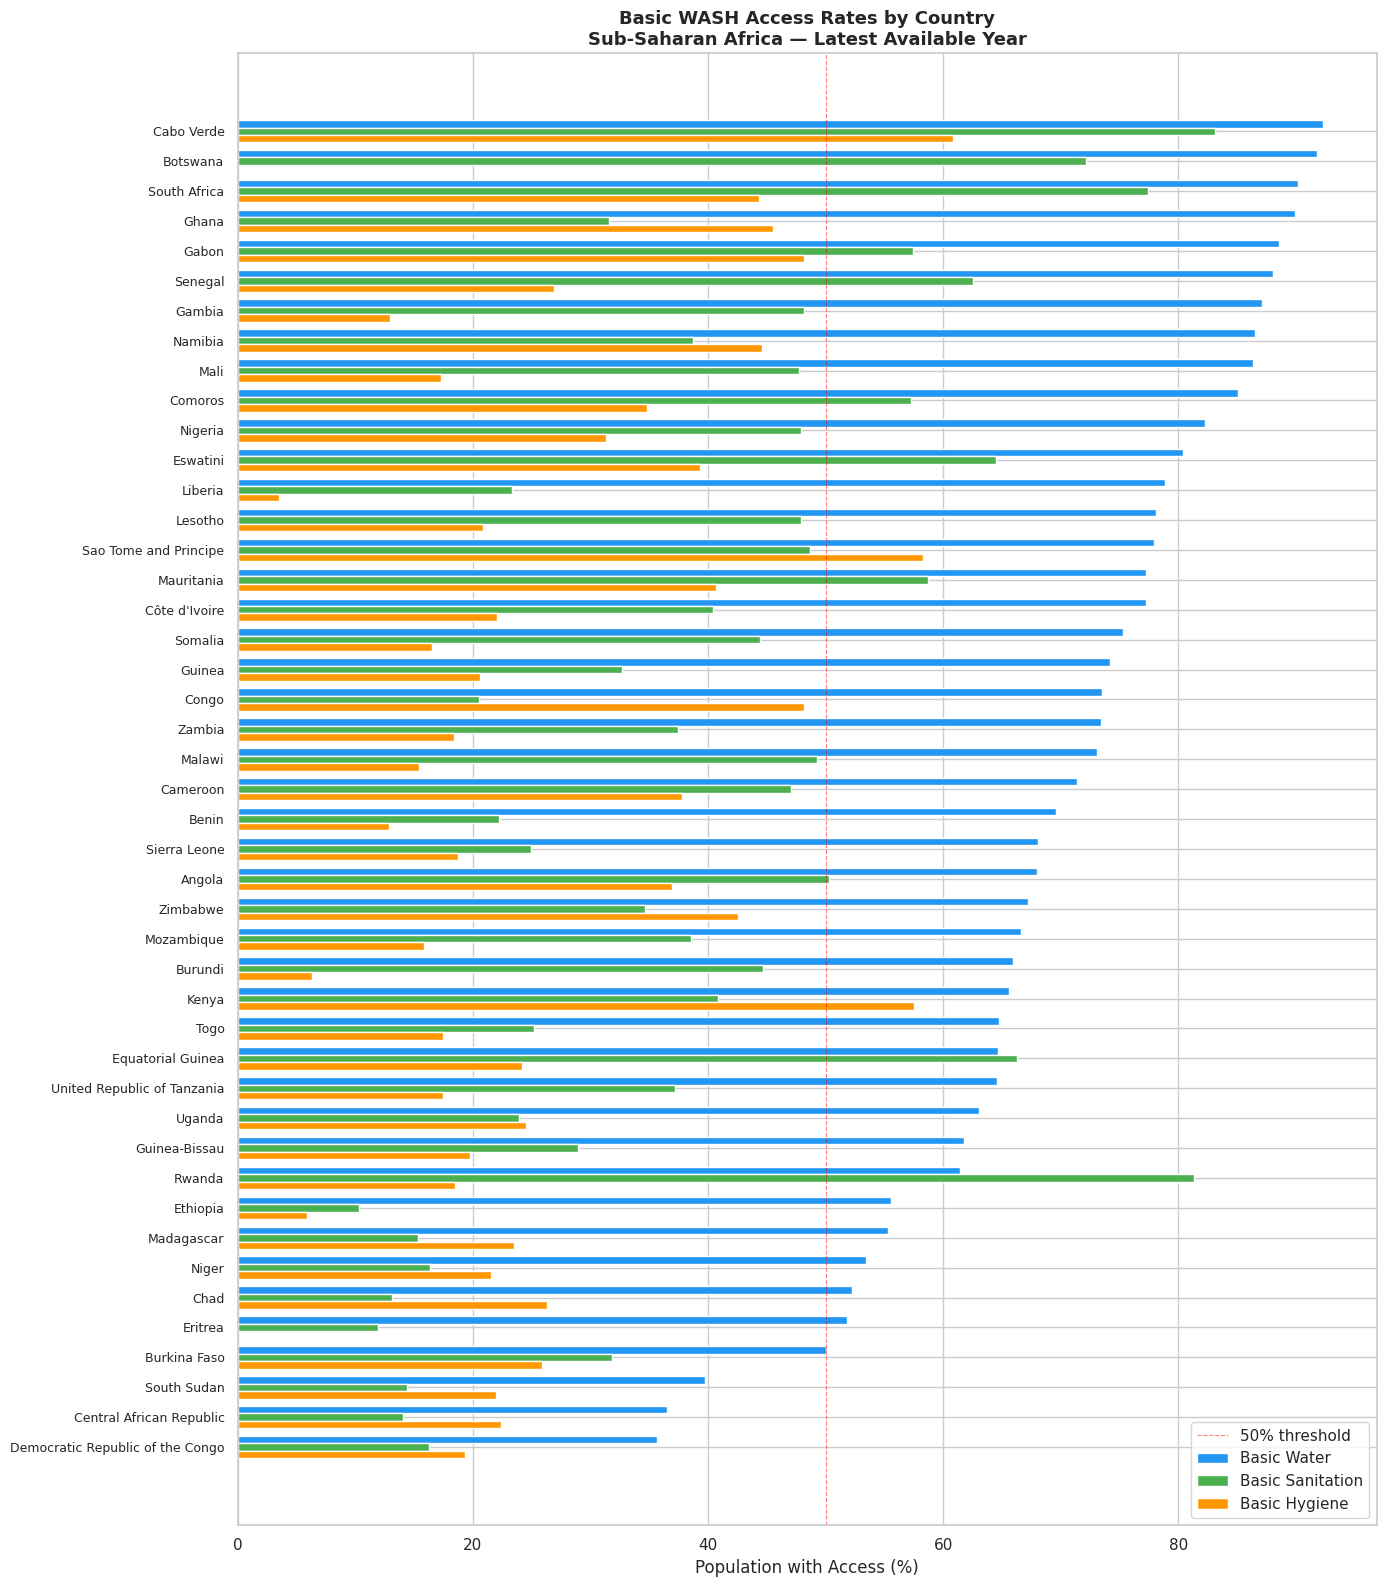

Chart 1 saved.


In [7]:
# Merge water, sanitation and hygiene latest into one dataframe
access = wat_latest[["Country", "Water_Basic_Total"]].merge(
    san_latest[["Country", "San_Basic_Total"]], on="Country"
).merge(
    hyg_latest[["Country", "Hyg_Basic_Total"]], on="Country", how="left"
).sort_values("Water_Basic_Total", ascending=True)

fig, ax = plt.subplots(figsize=(14, 16))

y = range(len(access))
bar_height = 0.25

ax.barh([i + bar_height for i in y], access["Water_Basic_Total"],
        height=bar_height, label="Basic Water", color="#2196F3")
ax.barh([i for i in y], access["San_Basic_Total"],
        height=bar_height, label="Basic Sanitation", color="#4CAF50")
ax.barh([i - bar_height for i in y], access["Hyg_Basic_Total"],
        height=bar_height, label="Basic Hygiene", color="#FF9800")

ax.set_yticks(list(y))
ax.set_yticklabels(access["Country"], fontsize=9)
ax.set_xlabel("Population with Access (%)")
ax.set_title("Basic WASH Access Rates by Country\nSub-Saharan Africa — Latest Available Year",
             fontsize=13, fontweight="bold")
ax.axvline(x=50, color="red", linestyle="--", linewidth=0.8, alpha=0.5, label="50% threshold")
ax.legend(loc="lower right")
plt.tight_layout()
plt.savefig("/content/chart1_access_by_country.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart 1 saved.")

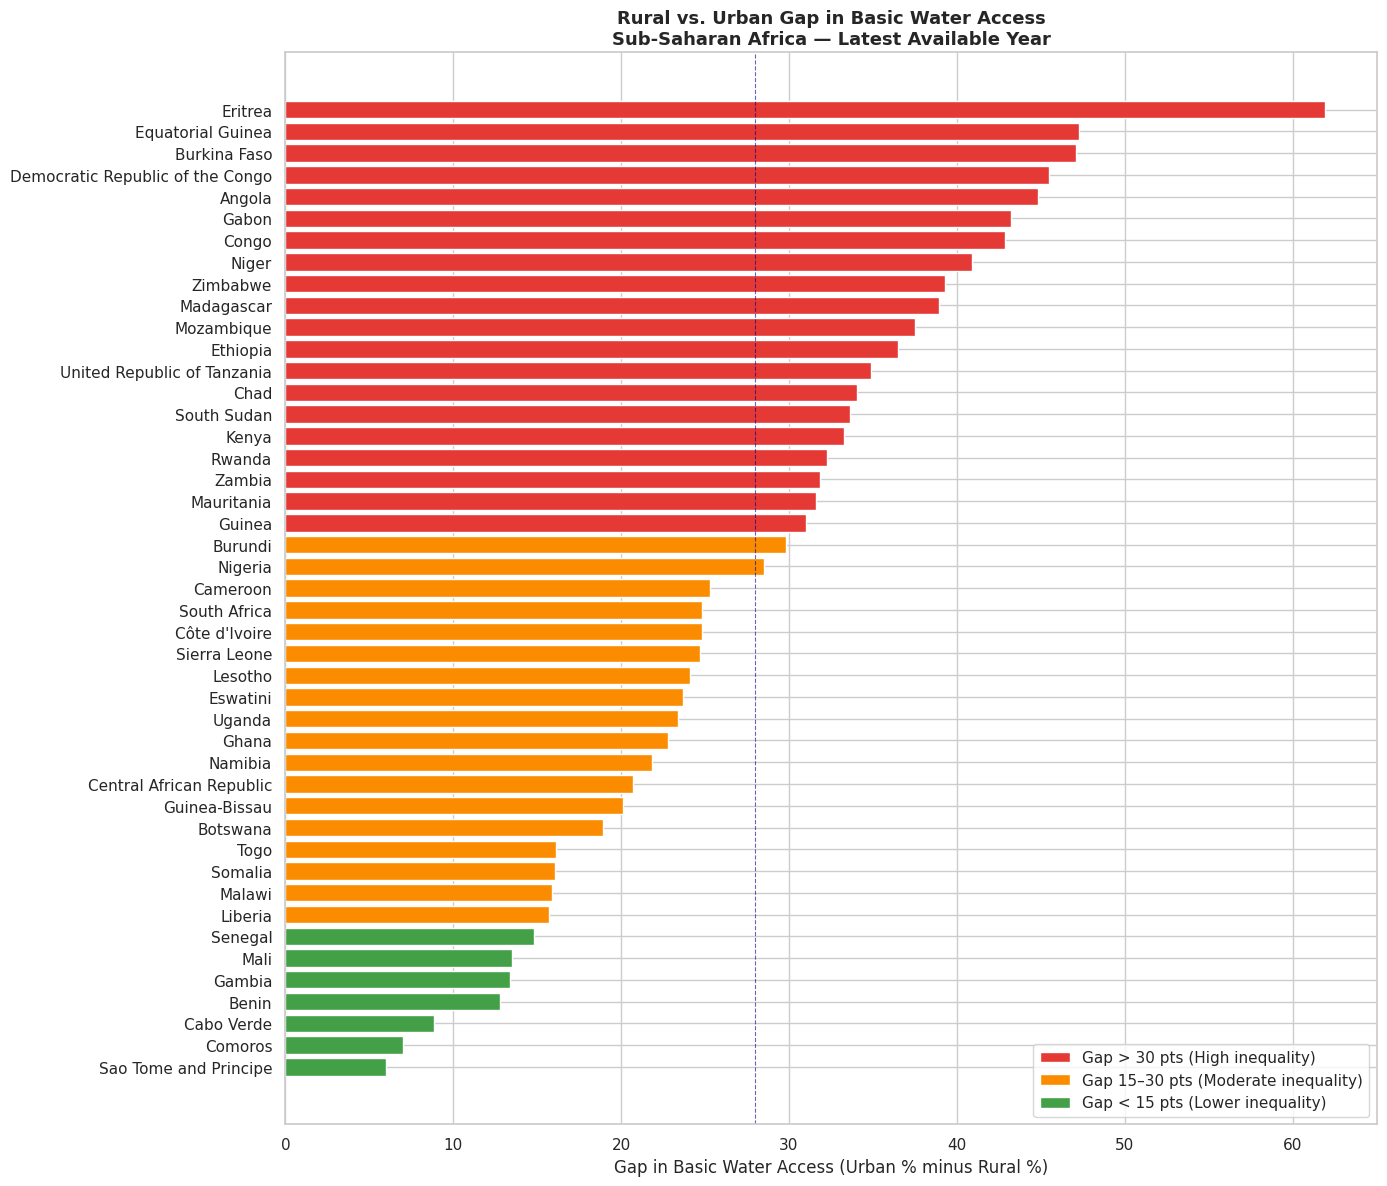

Chart 2 saved.


In [8]:
# Prepare gap data
gap_data = wat_latest[["Country", "Water_Basic_Rural", "Water_Basic_Urban"]].copy()
gap_data["Gap"] = gap_data["Water_Basic_Urban"] - gap_data["Water_Basic_Rural"]
gap_data = gap_data.dropna().sort_values("Gap", ascending=True)

fig, ax = plt.subplots(figsize=(14, 12))

colors = ["#E53935" if g > 30 else "#FB8C00" if g > 15 else "#43A047"
          for g in gap_data["Gap"]]

ax.barh(gap_data["Country"], gap_data["Gap"], color=colors)
ax.set_xlabel("Gap in Basic Water Access (Urban % minus Rural %)")
ax.set_title("Rural vs. Urban Gap in Basic Water Access\nSub-Saharan Africa — Latest Available Year",
             fontsize=13, fontweight="bold")
ax.axvline(x=28, color="navy", linestyle="--", linewidth=0.8,
           alpha=0.6, label=f"Regional average (28 pts)")
ax.legend()

# Color legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="#E53935", label="Gap > 30 pts (High inequality)"),
    Patch(facecolor="#FB8C00", label="Gap 15–30 pts (Moderate inequality)"),
    Patch(facecolor="#43A047", label="Gap < 15 pts (Lower inequality)")
]
ax.legend(handles=legend_elements, loc="lower right")
plt.tight_layout()
plt.savefig("/content/chart2_rural_urban_gap.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart 2 saved.")

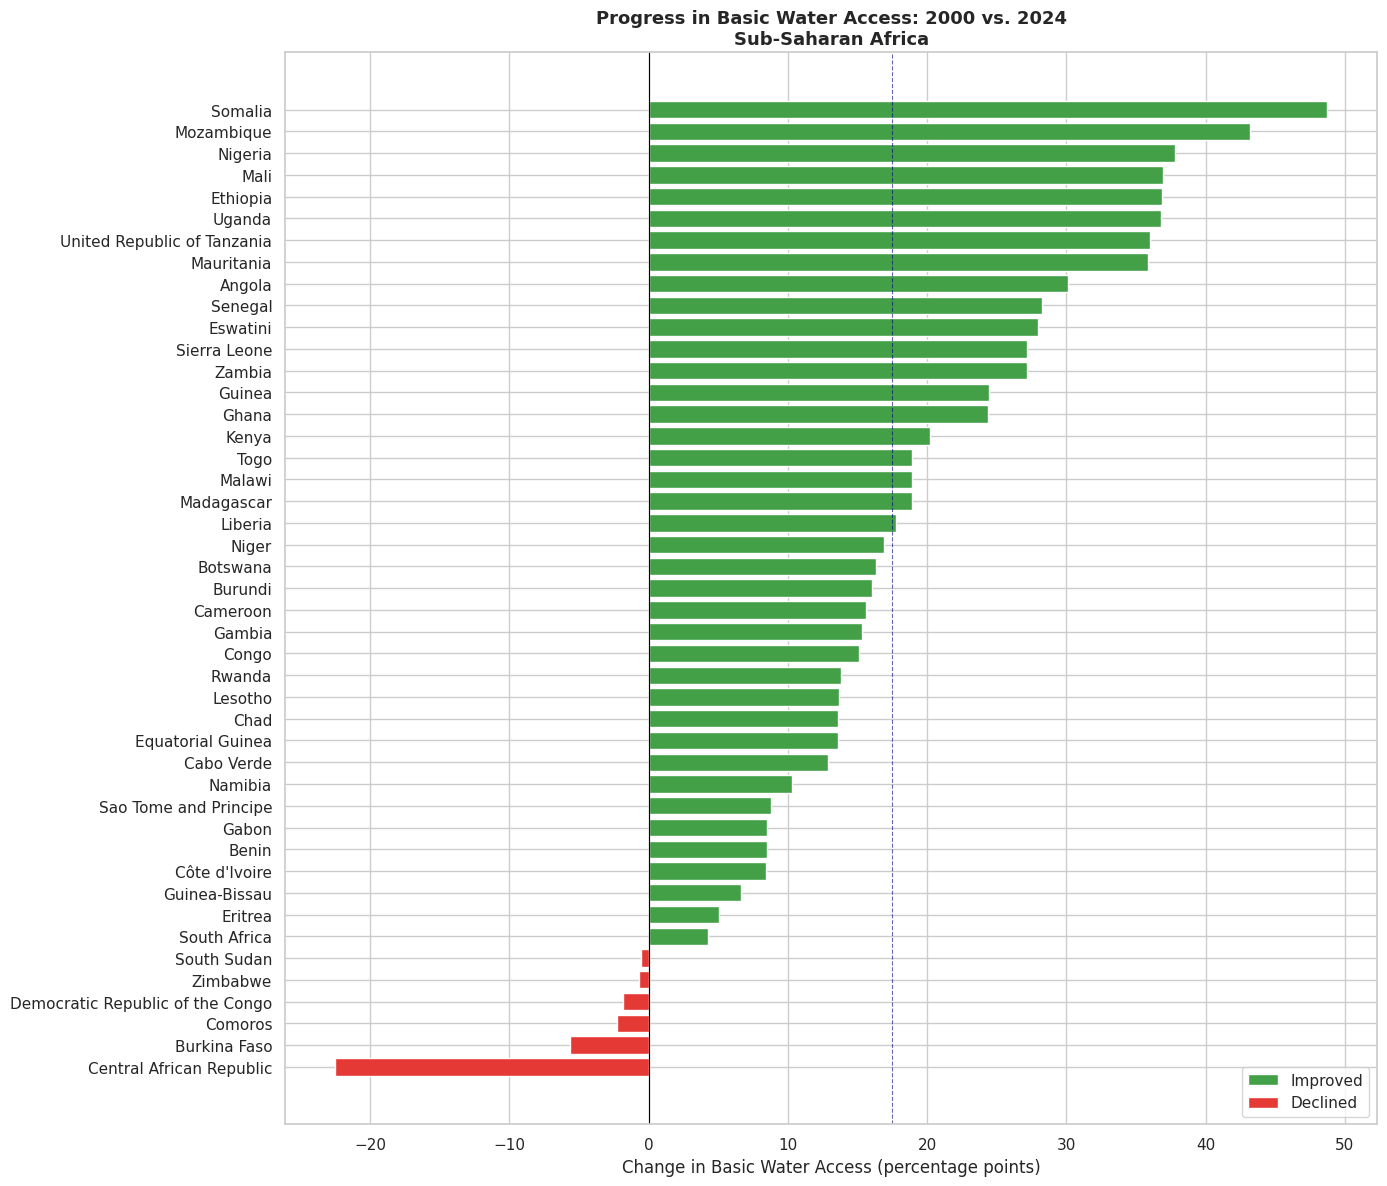

Chart 3 saved.


In [9]:
# Start and end values per country for water
earliest = wat_trend.sort_values("Year").groupby("Country").first().reset_index()
latest_w = wat_trend.sort_values("Year").groupby("Country").last().reset_index()

progress = earliest[["Country", "Water_Basic_Total"]].merge(
    latest_w[["Country", "Water_Basic_Total"]], on="Country",
    suffixes=("_2000", "_2024")
)
progress["Change"] = progress["Water_Basic_Total_2024"] - progress["Water_Basic_Total_2000"]
progress = progress.dropna().sort_values("Change", ascending=True)

fig, ax = plt.subplots(figsize=(14, 12))

colors = ["#E53935" if c < 0 else "#43A047" for c in progress["Change"]]
ax.barh(progress["Country"], progress["Change"], color=colors)
ax.set_xlabel("Change in Basic Water Access (percentage points)")
ax.set_title("Progress in Basic Water Access: 2000 vs. 2024\nSub-Saharan Africa",
             fontsize=13, fontweight="bold")
ax.axvline(x=0, color="black", linewidth=0.8)
ax.axvline(x=17.5, color="navy", linestyle="--", linewidth=0.8,
           alpha=0.6, label="Regional average (+17.5 pts)")

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="#43A047", label="Improved"),
    Patch(facecolor="#E53935", label="Declined")
]
ax.legend(handles=legend_elements, loc="lower right")
plt.tight_layout()
plt.savefig("/content/chart3_progress_2000_2024.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart 3 saved.")

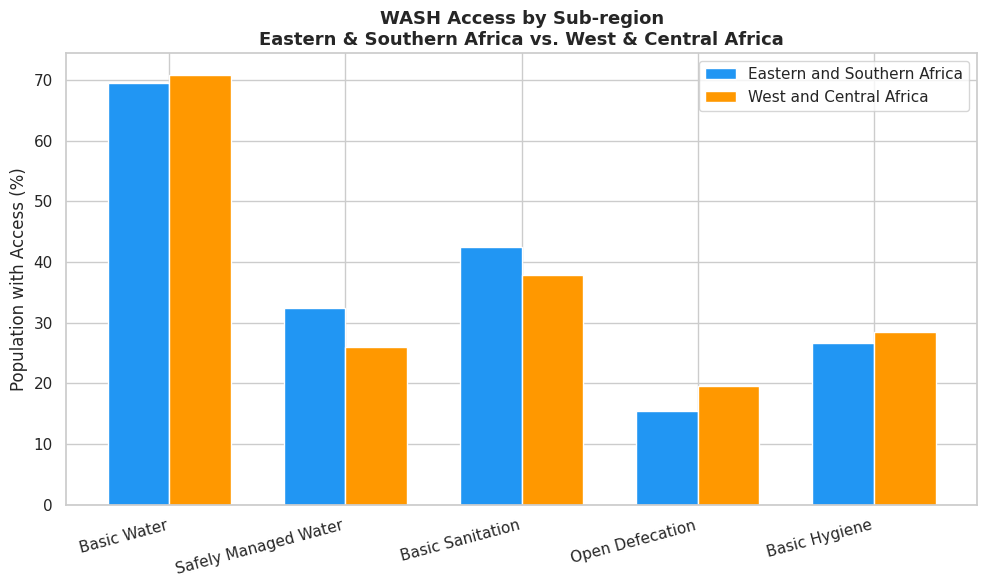

Chart 4 saved.


In [10]:
# Average access by UNICEF sub-region
subregion_wat = wat_latest.groupby("UNICEF_Region")[
    ["Water_Basic_Total", "Water_SafelyManaged_Total"]].mean()
subregion_san = san_latest.groupby("UNICEF_Region")[
    ["San_Basic_Total", "San_OpenDefecation_Total"]].mean()
subregion_hyg = hyg_latest.groupby("UNICEF_Region")[
    ["Hyg_Basic_Total"]].mean()

subregion = subregion_wat.join(subregion_san).join(subregion_hyg)
subregion.columns = ["Basic Water", "Safely Managed Water",
                     "Basic Sanitation", "Open Defecation", "Basic Hygiene"]

fig, ax = plt.subplots(figsize=(10, 6))

x = range(len(subregion.columns))
width = 0.35
regions = subregion.index.tolist()

ax.bar([i - width/2 for i in x], subregion.loc[regions[0]],
       width=width, label=regions[0], color="#2196F3")
ax.bar([i + width/2 for i in x], subregion.loc[regions[1]],
       width=width, label=regions[1], color="#FF9800")

ax.set_xticks(list(x))
ax.set_xticklabels(subregion.columns, rotation=15, ha="right")
ax.set_ylabel("Population with Access (%)")
ax.set_title("WASH Access by Sub-region\nEastern & Southern Africa vs. West & Central Africa",
             fontsize=13, fontweight="bold")
ax.legend()
plt.tight_layout()
plt.savefig("/content/chart4_subregion_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart 4 saved.")

## Step 8 — Export Summary Findings Table
We compile the key findings from our analysis into a single
summary table. This serves as a quick reference for the written
report.

In [11]:
# Continental overview
summary_data = {
    "Indicator": [
        "Basic Water Access",
        "Safely Managed Water",
        "Basic Sanitation Access",
        "Safely Managed Sanitation",
        "Open Defecation",
        "Basic Hygiene Access"
    ],
    "Regional_Average_Pct": [
        wat_latest["Water_Basic_Total"].mean().round(1),
        wat_latest["Water_SafelyManaged_Total"].mean().round(1),
        san_latest["San_Basic_Total"].mean().round(1),
        san_latest["San_SafelyManaged_Total"].mean().round(1),
        san_latest["San_OpenDefecation_Total"].mean().round(1),
        hyg_latest["Hyg_Basic_Total"].mean().round(1),
    ],
    "Best_Performer": [
        "Cabo Verde (92.3%)",
        "South Africa (68.0%)",
        "Cabo Verde (83.1%)",
        "Cabo Verde (73.8%)",
        "Gambia (0.0%)",
        "Cabo Verde (60.9%)",
    ],
    "Worst_Performer": [
        "DRC (35.7%)",
        "Niger (6.2%)",
        "Ethiopia (10.4%)",
        "Ethiopia (8.1%)",
        "Eritrea (67.0%)",
        "Liberia (3.5%)",
    ],
    "Avg_RuralUrban_Gap_Pts": [
        round(wat_latest["Water_RuralUrban_Gap"].mean(), 1),
        None,
        round(san_latest["San_RuralUrban_Gap"].mean(), 1),
        None,
        None,
        round(hyg_latest["Hyg_RuralUrban_Gap"].mean(), 1),
    ],
    "Avg_Progress_2000_2024_Pts": [
        17.5,
        None,
        17.6,
        None,
        -17.7,
        6.5,
    ]
}

summary_df = pd.DataFrame(summary_data)

print("=" * 60)
print("SUMMARY FINDINGS TABLE")
print("=" * 60)
print(summary_df.to_string(index=False))

# Export to Excel
summary_path = "/content/wash_summary_findings.xlsx"
summary_df.to_excel(summary_path, index=False)
print(f"\nSummary table exported to: {summary_path}")

# Also export as CSV
summary_df.to_csv("/content/wash_summary_findings.csv", index=False)
print("CSV version also exported.")

SUMMARY FINDINGS TABLE
                Indicator  Regional_Average_Pct       Best_Performer  Worst_Performer  Avg_RuralUrban_Gap_Pts  Avg_Progress_2000_2024_Pts
       Basic Water Access                  70.2   Cabo Verde (92.3%)      DRC (35.7%)                    28.0                        17.5
     Safely Managed Water                  28.9 South Africa (68.0%)     Niger (6.2%)                     NaN                         NaN
  Basic Sanitation Access                  40.0   Cabo Verde (83.1%) Ethiopia (10.4%)                    18.1                        17.6
Safely Managed Sanitation                  27.1   Cabo Verde (73.8%)  Ethiopia (8.1%)                     NaN                         NaN
          Open Defecation                  17.6        Gambia (0.0%)  Eritrea (67.0%)                     NaN                       -17.7
     Basic Hygiene Access                  27.6   Cabo Verde (60.9%)   Liberia (3.5%)                    16.5                         6.5

Summary ta